In [1]:
import os
os.chdir('../../..')
print(os.getcwd())

/Users/titonka/FAIRIS


In [13]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Simulation.libraries.SimulationLib.Environment import *
with open('logs/AllPPOTrainData_uniform_25_MW00V3','rb') as file:
    experiment_data1 = pickle.load(file)
with open('logs/AllPPOTrainData_uniform_25_MW10V3','rb') as file:
    experiment_data2 = pickle.load(file)    
experiment_data = [experiment_data1,experiment_data2]

In [3]:
WM00 = []
WM10 = []
WM20 = []
for data in experiment_data1:
    if data.maze_file == 'WM00':
        WM00.append(data)
    elif data.maze_file == 'WM10':
        WM10.append(data)
    else:
        WM20.append(data)
for data in experiment_data2:
    if data.maze_file == 'WM00':
        WM00.append(data)
    elif data.maze_file == 'WM10':
        WM10.append(data)
    else:
        WM20.append(data)

In [22]:
def plot_training_steps_for_maze(experiment_data):
    fig, (ax0,ax1) = plt.subplots(2,1, sharex= True, figsize = (13, 12))
    data1 = np.array(experiment_data[0][0].path_length_history)
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'o-')
    data1 = np.array(experiment_data[1][0].path_length_history)
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'o-')
    ax0.axhline(y = 15, color = 'r', linestyle = '-')
    ax1.axhline(y = 15, color = 'r', linestyle = '-')
    # ax2.plot(range(len(experiment_data[2].path_length_history)),experiment_data[2].path_length_history,'o-')
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Number of Actions")
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Number of Actions")
    # ax2.set_title("Maze: WM20")
    # ax2.set_xlabel("Training Episodes")
    # ax2.set_ylabel("Number of Actions")
    plt.suptitle('Place Cell Uniform 25x25 Network Training Path Length',fontsize=15)
    return fig

In [5]:
print(len(experiment_data[0][0].episodes))

TypeError: 'ExperimentLogger' object is not subscriptable

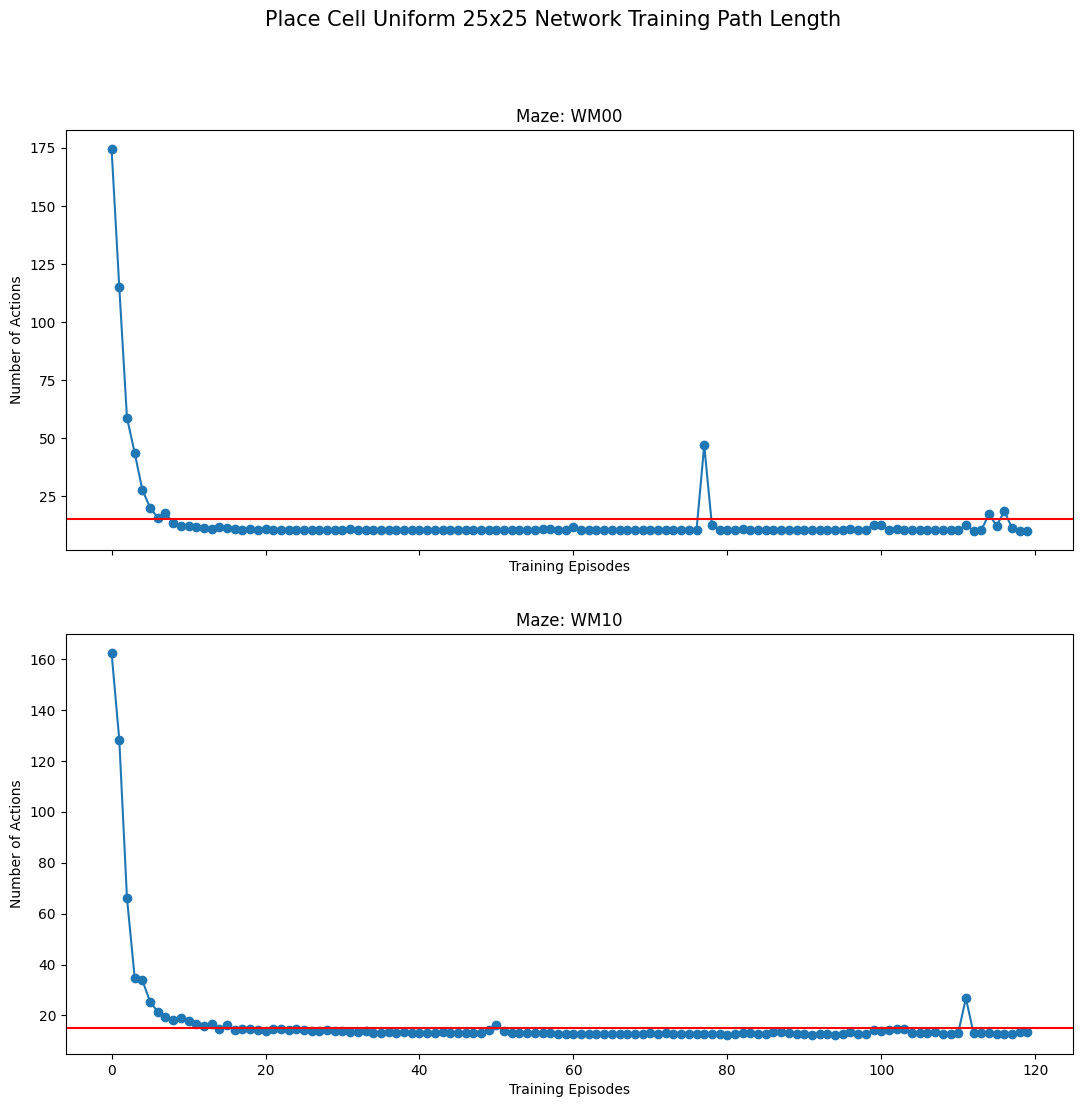

In [23]:
fig = plot_training_steps_for_maze(experiment_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_steps.png')

In [3]:
def plot_training_reward_for_maze(experiment_data):
    fig, (ax0,ax1) = plt.subplots(1,2, sharex= True, figsize = (6, 12))
    data1 = np.array(experiment_data[0][0].score_history)
    data1 = np.average(data1.reshape(-1,4),axis=1)
    ax0.plot(range(len(data1)),data1,'o-')
    data1 = np.array(experiment_data[1][0].score_history)
    data1 = np.average(data1.reshape(-1,4),axis=1)
    ax1.plot(range(len(data1)),data1,'o-')
    # ax2.plot(range(len(experiment_data[2].score_history)),experiment_data[2].score_history,'o-')
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Number of Actions")
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Number of Actions")
    # ax2.set_title("Maze: WM20")
    # ax2.set_xlabel("Training Episodes")
    # ax2.set_ylabel("Number of Actions")
    plt.suptitle('Place Cell Uniform 25x25 Network Training Reward',fontsize=15)
    return fig

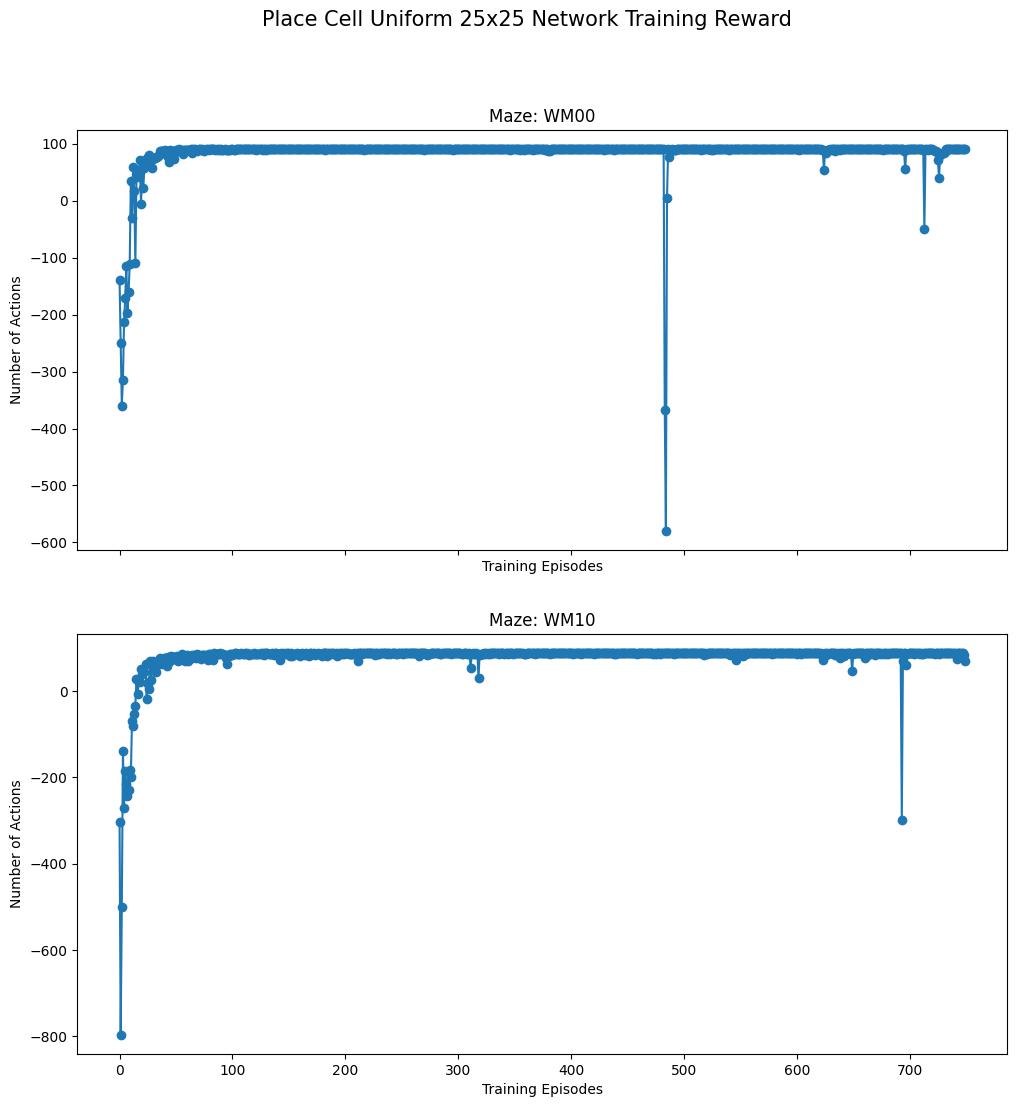

In [21]:
fig = plot_training_reward_for_maze(experiment_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_reward.png')

In [6]:
def plot_paths(maze, experiment,PC_ver = '6x6'):
    World = Maze('Simulation/worlds/mazes/Experiment1/'+maze+'.xml')
    i = experiment
    World.maze_figure_ax.plot(experiment_data[i].episodes[-1].path_xs,experiment_data[i].episodes[-1].path_ys)
    World.maze_figure_ax.plot(experiment_data[i].episodes[-2].path_xs,experiment_data[i].episodes[-2].path_ys)
    World.maze_figure_ax.plot(experiment_data[i].episodes[-3].path_xs,experiment_data[i].episodes[-3].path_ys)
    World.maze_figure_ax.plot(experiment_data[i].episodes[-4].path_xs,experiment_data[i].episodes[-4].path_ys)
    plt.suptitle('PC Uniform '+PC_ver)
   
    return World.maze_figure


In [11]:
def plot_last_paths(experiment_data):
    maze_figure, maze_figure_ax = plt.subplots(1, 2, figsize=(12, 6))
    maze = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[0][0].maze_file+'.xml')
    maze2 = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[1][0].maze_file+'.xml')
    maze_figure_ax[0].add_collection(pycol.LineCollection(maze.walls, linewidths=2))
    maze_figure_ax[1].add_collection(pycol.LineCollection(maze2.walls, linewidths=2))
    # maze_figure_ax[2].add_collection(pycol.LineCollection(maze.walls, linewidths=2))
    
    for point in maze.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='green')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)
    for point in maze.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='blue')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)
    for point in maze.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='red')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)

    for i in range(len(experiment_data)):
        maze_figure_ax[i].plot(experiment_data[i][0].episodes[-1].path_xs,experiment_data[i][0].episodes[-1].path_ys)
        maze_figure_ax[i].plot(experiment_data[i][0].episodes[-2].path_xs,experiment_data[i][0].episodes[-2].path_ys)
        maze_figure_ax[i].plot(experiment_data[i][0].episodes[-3].path_xs,experiment_data[i][0].episodes[-3].path_ys)
        maze_figure_ax[i].plot(experiment_data[i][0].episodes[-4].path_xs,experiment_data[i][0].episodes[-4].path_ys)
        maze_figure_ax[i].set_title("PC Version")


    maze_figure_ax[0].set_ylim(-4.25, 4.25)
    maze_figure_ax[0].set_xlim(-4.25, 4.25)
    maze_figure_ax[0].margins(0.1)
    maze_figure_ax[1].set_ylim(-4.25, 4.25)
    maze_figure_ax[1].set_xlim(-4.25, 4.25)
    maze_figure_ax[1].margins(0.1)
    # maze_figure_ax[2].set_ylim(-4.25, 4.25)
    # maze_figure_ax[2].set_xlim(-4.25, 4.25)
    # maze_figure_ax[2].margins(0.1)
    return maze_figure

In [9]:
def plot_last_paths_same_maze(experiment_data):
    maze_figure, maze_figure_ax = plt.subplots(1, 3, figsize=(12, 6))
    maze1 = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[0].maze_file+'.xml')
    maze2 = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[1].maze_file+'.xml')
    maze3 = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[2].maze_file+'.xml')

    maze_figure_ax[0].add_collection(pycol.LineCollection(maze1.walls, linewidths=2))
    maze_figure_ax[1].add_collection(pycol.LineCollection(maze2.walls, linewidths=2))
    maze_figure_ax[2].add_collection(pycol.LineCollection(maze3.walls, linewidths=2))
    
    for point in maze1.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax[0].add_patch(new_crc)
    for point in maze2.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax[1].add_patch(new_crc)
    for point in maze2.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax[2].add_patch(new_crc)
    for point in maze1.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax[0].add_patch(new_crc)
    for point in maze2.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax[1].add_patch(new_crc)
    for point in maze3.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax[2].add_patch(new_crc)

    for point in maze1.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax[0].add_patch(new_crc)
    for point in maze2.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax[1].add_patch(new_crc)
    for point in maze3.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax[2].add_patch(new_crc)

    for i in range(len(experiment_data)):
        maze_figure_ax[i].plot(experiment_data[i].episodes[-1].path_xs,experiment_data[i].episodes[-1].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-2].path_xs,experiment_data[i].episodes[-2].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-3].path_xs,experiment_data[i].episodes[-3].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-4].path_xs,experiment_data[i].episodes[-4].path_ys)
        maze_figure_ax[i].set_title("Maze: " + experiment_data[i].maze_file)


    maze_figure_ax[0].set_ylim(-4.25, 4.25)
    maze_figure_ax[0].set_xlim(-4.25, 4.25)
    maze_figure_ax[0].margins(0.1)
    maze_figure_ax[1].set_ylim(-4.25, 4.25)
    maze_figure_ax[1].set_xlim(-4.25, 4.25)
    maze_figure_ax[1].margins(0.1)
    # maze_figure_ax[2].set_ylim(-4.25, 4.25)
    # maze_figure_ax[2].set_xlim(-4.25, 4.25)
    # maze_figure_ax[2].margins(0.1)
    return maze_figure

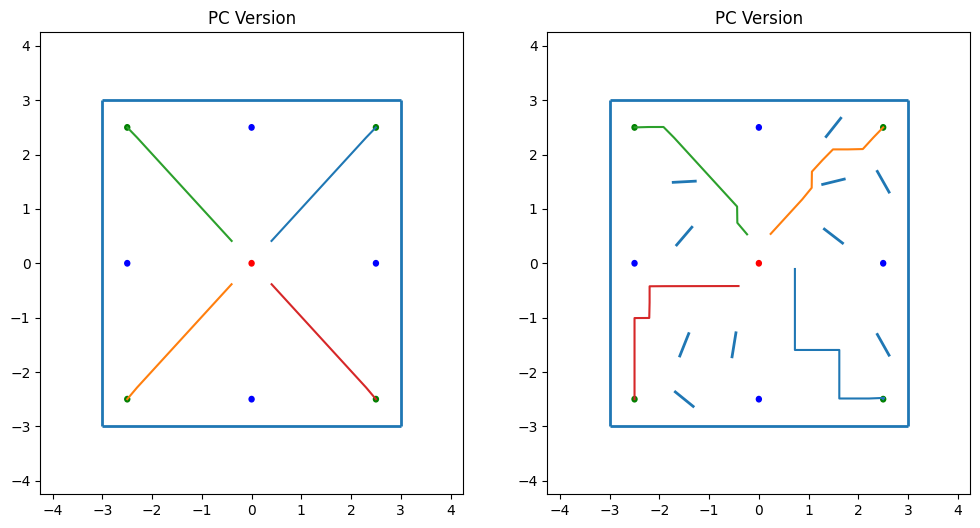

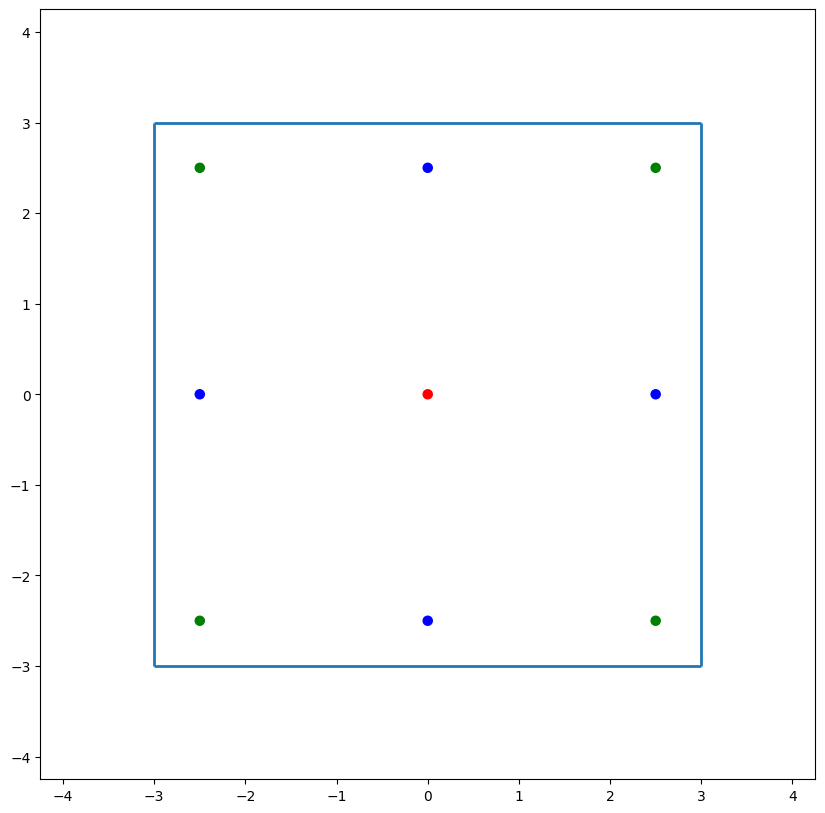

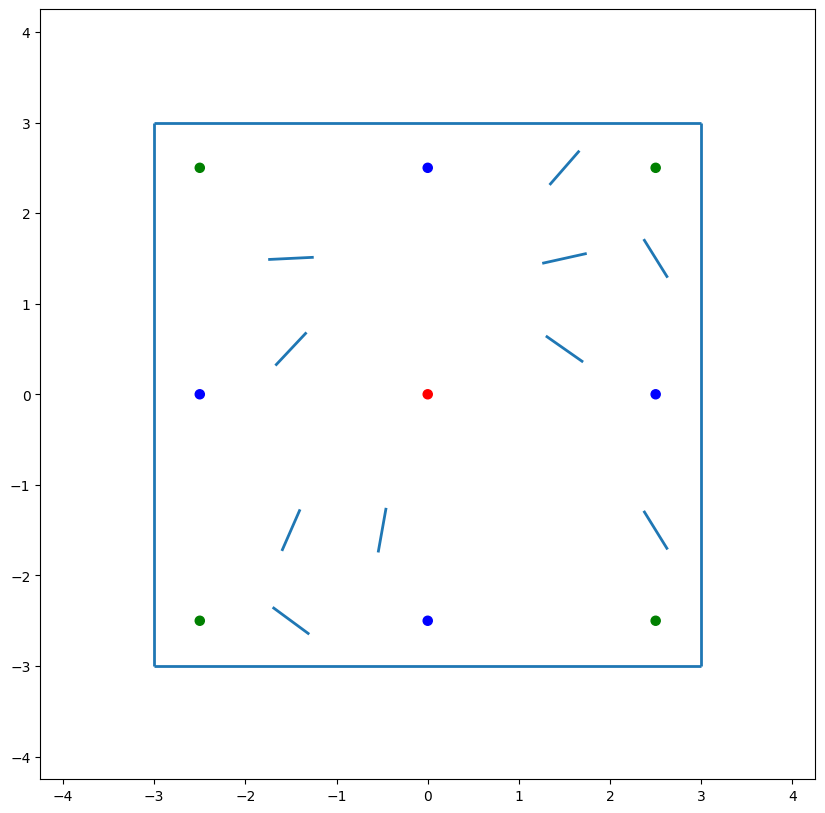

In [15]:
fig = plot_last_paths(experiment_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_paths.png')